In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
!git clone https://github.com/Adhishree22/Visa_Fundamental_Analysis.git
%cd Visa_Fundamental_Analysis

Cloning into 'Visa_Fundamental_Analysis'...
remote: Enumerating objects: 1206, done.
remote: Counting objects: 100% (177/177), done.
remote: Compressing objects: 100% (169/169), done.
remote: Total 1206 (delta 38), reused 21 (delta 8), pack-reused 1029 (from 1)
Receiving objects: 100% (1206/1206), 428.70 KiB | 14.29 MiB/s, done.
Resolving deltas: 100% (769/769), done.
/content/Visa_Fundamental_Analysis


In [3]:
# Financial Dataframe
# ====================================================

from data.pipeline import *

ticker="V"

df = build_dataset(ticker)

df.T

V dataset built successfully


Year,2022,2023,2024,2025
Revenue,2.931000e+04,3.265300e+04,3.592600e+04,4.000000e+04
CostOfRevenue,5.733000e+03,6.567000e+03,7.042000e+03,7.855000e+03
GrossProfit,2.357700e+04,2.608600e+04,2.888400e+04,3.214500e+04
OperatingExpense,3.896000e+03,4.159000e+03,4.827000e+03,5.589000e+03
OperatingIncome,1.968100e+04,2.192700e+04,2.405700e+04,2.655600e+04
...,...,...,...,...
Closing,1.725800e+02,2.252400e+02,2.713700e+02,3.393000e+02
PreferredStockDividend,3.270000e+02,2.840000e+02,2.860000e+02,2.050000e+02
NetIncomeCommon,1.463000e+04,1.698900e+04,1.945700e+04,1.985300e+04
Shares,2.086435e+09,2.031762e+09,1.980513e+09,1.933259e+09


In [4]:
print("Shape of DF ",df.shape)
print("\nColumn Names of df: \n")
df.columns

Shape of DF  (4, 69)

Column Names of df: 



Index(['Revenue', 'CostOfRevenue', 'GrossProfit', 'OperatingExpense',
       'OperatingIncome', 'OtherExpense', 'EBT', 'Taxes', 'NetIncome',
       'ChangeWC', 'OperatingCashFlow', 'OtherNonCashItems',
       'AmortizationOfIntangibles', 'DeferredTax',
       'GoodwillAndOtherIntangibleAssets', 'OperatingGainsLosses',
       'InvestingCashFlow', 'NetInvestmentPurchaseAndSale',
       'NetBusinessPurchaseAndSale', 'NetOtherInvestingChanges',
       'FinancingCashFlow', 'NetOtherFinancingCharges', 'FreeCashFlow',
       'BeginningCash', 'EndingCash', 'FX', 'ChangeInCash', 'TotalAssets',
       'OtherNonCurrentAssets', 'InvestmentsAndAdvances', 'TotalLiabilities',
       'NonCurrentDeferredLiabilities', 'OtherNonCurrentLiabilities', 'EBITDA',
       'TotalDebt', 'LongTermDebt', 'ShortTermDebt', 'Interest', 'DebtIssued',
       'Repayment', 'Equity', 'Dividends', 'SBC', 'ShareIssued', 'BuyBacks',
       'CommonStockEquity', 'PreferredStockEquity', 'PPE', 'Depreciation',
       'Capex', 'Cu

In [5]:
# Forecast Function (Driver Variables, Revenue)
# Revenue ≈ Payment Volume × Take Rate
# ====================================================

from models.forecast import *

periods=5
forecast = build_forecast(df, periods)

full_df = pd.concat([df, forecast]).sort_index()
full_df[["Revenue", "PaymentVolume", "Transactions"]]

,Revenue,PaymentVolume,Transactions
2022,29310.0,11600000.0,1920000.0
2023,32653.0,12300000.0,2126000.0
2024,35926.0,13200000.0,2338000.0
2025,40000.0,14200000.0,2575000.0
2026,43716.0,15000000.0,2784000.0
2027,47739.0,15870000.0,3001700.0
2028,51925.0,16740000.0,3219400.0
2029,56275.0,17610000.0,3437100.0
2030,60787.0,18480000.0,3654800.0


In [6]:
#Debt Schedule
# ====================================================

from models.schedules.debt import *

forecast = build_debt_schedule(df, forecast)

forecast = forecast.round(0)
full_df = pd.concat([df, forecast])

full_df[["EBITDA","TotalDebt","LongTermDebt","ShortTermDebt", "Interest", "DebtIssued", "Repayment","DebtAdjustment"]]

,EBITDA,TotalDebt,LongTermDebt,ShortTermDebt,Interest,DebtIssued,Repayment,DebtAdjustment
2022,19535.0,22450.0,20200.0,2250.0,538.0,3218.0,-1000.0,NaN
2023,22624.0,20463.0,20463.0,0.0,644.0,0.0,-2250.0,263.0
2024,25591.0,20836.0,20836.0,0.0,641.0,0.0,0.0,373.0
2025,26003.0,25171.0,19602.0,5569.0,589.0,3924.0,0.0,411.0
2026,29746.0,21360.0,20289.0,1070.0,637.0,1339.0,-5569.0,418.0
2027,32483.0,25273.0,24006.0,1266.0,638.0,4526.0,-1070.0,457.0
2028,35332.0,28406.0,26983.0,1423.0,734.0,3903.0,-1266.0,497.0
2029,38292.0,31243.0,29678.0,1566.0,816.0,3722.0,-1423.0,539.0
2030,41362.0,34000.0,32296.0,1704.0,893.0,3741.0,-1566.0,582.0


In [7]:
#Income Statement
# ====================================================

from models.statements.income_statement import *

forecast = build_income_statement(df, forecast)

forecast = forecast.round(0)
full_df = pd.concat([df, forecast])

full_df[["Revenue","CostOfRevenue","GrossProfit","OperatingExpense","OperatingIncome","OtherExpense","Interest","EBT","Taxes","NetIncome"]]

,Revenue,CostOfRevenue,GrossProfit,OperatingExpense,OperatingIncome,OtherExpense,Interest,EBT,Taxes,NetIncome
2022,29310.0,5733.0,23577.0,3896.0,19681.0,-1007.0,538.0,18136.0,3179.0,14957.0
2023,32653.0,6567.0,26086.0,4159.0,21927.0,-246.0,644.0,21037.0,3764.0,17273.0
2024,35926.0,7042.0,28884.0,4827.0,24057.0,500.0,641.0,23916.0,4173.0,19743.0
2025,40000.0,7855.0,32145.0,5589.0,26556.0,-1773.0,589.0,24194.0,4136.0,20058.0
2026,43716.0,8624.0,35092.0,5840.0,29252.0,-916.0,637.0,27699.0,4845.0,22854.0
2027,47739.0,9418.0,38321.0,6378.0,31944.0,-1000.0,638.0,30306.0,5301.0,25005.0
2028,51925.0,10244.0,41681.0,6937.0,34745.0,-1088.0,734.0,32923.0,5759.0,27164.0
2029,56275.0,11102.0,45173.0,7518.0,37655.0,-1179.0,816.0,35661.0,6237.0,29423.0
2030,60787.0,11992.0,48795.0,8121.0,40674.0,-1273.0,893.0,38508.0,6736.0,31773.0


In [8]:
#Equity Schedule
# ====================================================

from models.schedules.equity import *

forecast = build_equity_schedule(df, forecast)

forecast = forecast.round(0)
full_df = pd.concat([df, forecast])

full_df[["NetIncome", "Dividends","BuyBacks","ShareIssued","SBC","EquityAdjustment","Equity","CommonStockEquity","PreferredStockEquity"]]

,NetIncome,Dividends,BuyBacks,ShareIssued,SBC,EquityAdjustment,Equity,CommonStockEquity,PreferredStockEquity
2022,14957.0,-3203.0,-11589.0,196.0,602.0,NaN,35581.0,33257.0,2324.0
2023,17273.0,-3751.0,-12101.0,260.0,765.0,706.0,38733.0,37035.0,1698.0
2024,19743.0,-4217.0,-16713.0,335.0,850.0,406.0,39137.0,38106.0,1031.0
2025,20058.0,-4634.0,-18316.0,396.0,897.0,371.0,37909.0,37164.0,745.0
2026,22854.0,-5005.0,-18527.0,369.0,984.0,615.0,39200.0,38167.0,1033.0
2027,25005.0,-5476.0,-20271.0,403.0,1075.0,671.0,40608.0,39538.0,1070.0
2028,27164.0,-5948.0,-22021.0,439.0,1169.0,730.0,42140.0,41030.0,1110.0
2029,29423.0,-6443.0,-23852.0,475.0,1267.0,792.0,43801.0,42647.0,1154.0
2030,31773.0,-6958.0,-25758.0,514.0,1368.0,855.0,45596.0,44395.0,1201.0


In [9]:
#PPE Schedule
# ====================================================

from models.schedules.ppe import *

forecast = build_ppe_schedule(df, forecast)

forecast = forecast.round(0)
full_df = pd.concat([df, forecast])

full_df[["PPE","Depreciation","Capex","PPEAdjustment"]]

,PPE,Depreciation,Capex,PPEAdjustment
2022,3223.0,771.0,-970.0,NaN
2023,3425.0,867.0,-1059.0,10.0
2024,3824.0,955.0,-1257.0,97.0
2025,4236.0,955.0,-1482.0,-115.0
2026,4717.0,1025.0,-1503.0,2.0
2027,5220.0,1141.0,-1642.0,2.0
2028,5745.0,1263.0,-1786.0,2.0
2029,6293.0,1390.0,-1935.0,2.0
2030,6864.0,1522.0,-2091.0,3.0


In [10]:
# Cash Flow Statement (Operating)
# ====================================================

from models.statements.cashflow_operating import *

forecast = build_operating_cashflow(df, forecast)

forecast = forecast.round(0)
full_df = pd.concat([df, forecast])

full_df[["NetIncome","Depreciation","AmortizationOfIntangibles","SBC","DeferredTax","OtherNonCashItems"
,"ChangeWC","OperatingGainsLosses","OperatingCashFlow"]].T

,2022,2023,2024,2025,2026,2027,2028,2029,2030
NetIncome,14957.0,17273.0,19743.0,20058.0,22854.0,25005.0,27164.0,29423.0,31773.0
Depreciation,771.0,867.0,955.0,955.0,1025.0,1141.0,1263.0,1390.0,1522.0
AmortizationOfIntangibles,90.0,76.0,79.0,79.0,86.0,86.0,85.0,85.0,85.0
SBC,602.0,765.0,850.0,897.0,984.0,1075.0,1169.0,1267.0,1368.0
DeferredTax,-336.0,-483.0,-100.0,152.0,-277.0,-308.0,-341.0,-376.0,-411.0
OtherNonCashItems,10158.0,12175.0,13761.0,15817.0,16019.0,17527.0,19040.0,20624.0,22271.0
ChangeWC,-7657.0,-10022.0,-15432.0,-15172.0,-13839.0,-14982.0,-15589.0,-16200.0,-16803.0
OperatingGainsLosses,264.0,104.0,94.0,87.0,130.0,142.0,154.0,167.0,181.0
OperatingCashFlow,18849.0,20755.0,19950.0,23059.0,26982.0,29685.0,32945.0,36380.0,39985.0


In [11]:
# Cash Flow Statement (Investing)
# ====================================================

from models.statements.cashflow_investing import *

forecast = build_investing_cashflow(df, forecast)

forecast = forecast.round(0)
full_df = pd.concat([df, forecast])

full_df[["Capex","NetInvestmentPurchaseAndSale","NetBusinessPurchaseAndSale","NetOtherInvestingChanges","InvestingCashFlow"]]

,Capex,NetInvestmentPurchaseAndSale,NetBusinessPurchaseAndSale,NetOtherInvestingChanges,InvestingCashFlow
2022,-970.0,-1498.0,-1948.0,128.0,-4288.0
2023,-1059.0,-922.0,0.0,-25.0,-2006.0
2024,-1257.0,339.0,-915.0,-93.0,-1926.0
2025,-1482.0,2956.0,-887.0,121.0,708.0
2026,-1503.0,-411.0,-1041.0,44.0,-2911.0
2027,-1642.0,-449.0,-1137.0,48.0,-3180.0
2028,-1786.0,-488.0,-1237.0,52.0,-3459.0
2029,-1935.0,-529.0,-1341.0,57.0,-3748.0
2030,-2091.0,-571.0,-1448.0,61.0,-4049.0


In [12]:
# Cash Flow Statement (Financing)
# ====================================================

from models.statements.cashflow_financing import *

forecast = build_financing_cashflow(df, forecast)

forecast = forecast.round(0)
full_df = pd.concat([df, forecast])

full_df[["ShareIssued","BuyBacks","DebtIssued","Repayment","Dividends","NetOtherFinancingCharges","FinancingCashFlow"]]

,ShareIssued,BuyBacks,DebtIssued,Repayment,Dividends,NetOtherFinancingCharges,FinancingCashFlow
2022,196.0,-11589.0,3218.0,-1000.0,-3203.0,-318.0,-12696.0
2023,260.0,-12101.0,0.0,-2250.0,-3751.0,70.0,-17772.0
2024,335.0,-16713.0,0.0,0.0,-4217.0,-38.0,-20633.0
2025,396.0,-18316.0,3924.0,0.0,-4634.0,-333.0,-18963.0
2026,369.0,-18527.0,1339.0,-5569.0,-5005.0,-138.0,-27531.0
2027,403.0,-20271.0,4526.0,-1070.0,-5476.0,-163.0,-22051.0
2028,439.0,-22021.0,3903.0,-1266.0,-5948.0,-183.0,-25076.0
2029,475.0,-23852.0,3722.0,-1423.0,-6443.0,-201.0,-27722.0
2030,514.0,-25758.0,3741.0,-1566.0,-6958.0,-219.0,-30246.0


In [13]:
#Cash Balance and Free Cash Flow
# ====================================================

from models.statements.cash_balance import *

forecast = build_cash_balance(df, forecast)

forecast = forecast.round(0)
full_df = pd.concat([df, forecast])

full_df[["FreeCashFlow","OperatingCashFlow","InvestingCashFlow","FinancingCashFlow","ChangeInCash",
         "BeginningCash","FX","EndingCash"]]

,FreeCashFlow,OperatingCashFlow,InvestingCashFlow,FinancingCashFlow,ChangeInCash,BeginningCash,FX,EndingCash
2022,17879.0,18849.0,-4288.0,-12696.0,1865.0,19799.0,-1287.0,20377.0
2023,19696.0,20755.0,-2006.0,-17772.0,977.0,20377.0,636.0,21990.0
2024,18693.0,19950.0,-1926.0,-20633.0,-2609.0,21990.0,382.0,19763.0
2025,21577.0,23059.0,708.0,-18963.0,4804.0,19763.0,420.0,24987.0
2026,25479.0,26982.0,-2911.0,-27531.0,-3460.0,24987.0,-2.0,21525.0
2027,28043.0,29685.0,-3180.0,-22051.0,4454.0,21525.0,-2.0,25977.0
2028,31159.0,32945.0,-3459.0,-25076.0,4410.0,25977.0,-2.0,30385.0
2029,34445.0,36380.0,-3748.0,-27722.0,4910.0,30385.0,-2.0,35292.0
2030,37894.0,39985.0,-4049.0,-30246.0,5690.0,35292.0,-3.0,40980.0


In [14]:
#Working Capital Schedule
# ====================================================

from models.schedules.working_capital import *

forecast = build_working_capital(df, forecast)

forecast = forecast.round(0)
full_df = pd.concat([df, forecast])

full_df[["CurrentAssets","CashAndCashEquivalents","OtherShortTermInvestments","EndingCash","CashAdjustment","Receivables","RestrictedCash"
,"OtherCurrentAssets","CurrentLiabilities","ShortTermDebt","PayablesAndAccruedExpenses","Pension","OtherCurrentLiabilities","WorkingCapital"]].T

,2022,2023,2024,2025,2026,2027,2028,2029,2030
CurrentAssets,30205.0,33532.0,34033.0,37766.0,37571.0,43100.0,48665.0,54722.0,61506.0
CashAndCashEquivalents,15689.0,16286.0,11975.0,17164.0,14944.0,18035.0,21095.0,24502.0,28451.0
OtherShortTermInvestments,2833.0,3842.0,3200.0,1833.0,3103.0,3744.0,4380.0,5087.0,5907.0
EndingCash,20377.0,21990.0,19763.0,24987.0,21525.0,25977.0,30385.0,35292.0,40980.0
CashAdjustment,-1855.0,-1862.0,-4588.0,-5990.0,-3478.0,-4198.0,-4910.0,-5703.0,-6622.0
Receivables,3952.0,4474.0,7015.0,7317.0,6993.0,7637.0,8306.0,9002.0,9724.0
RestrictedCash,3791.0,4769.0,6613.0,6615.0,6807.0,7434.0,8085.0,8763.0,9465.0
OtherCurrentAssets,3940.0,4161.0,5230.0,4837.0,5724.0,6250.0,6798.0,7368.0,7959.0
CurrentLiabilities,20853.0,23098.0,26517.0,35048.0,32636.0,35737.0,38917.0,42201.0,45597.0
ShortTermDebt,2250.0,0.0,0.0,5569.0,1070.0,1266.0,1423.0,1566.0,1704.0


In [15]:
#Balance Sheet
# ====================================================

from models.statements.balance_sheet import *

forecast = build_balance_sheet(df, forecast)

full_df = pd.concat([df, forecast])

full_df[["BalanceSheetAdjustment","TotalAssets","CurrentAssets","PPE","GoodwillAndOtherIntangibleAssets","OtherNonCurrentAssets","InvestmentsAndAdvances"
,"TotalLiabilities","CurrentLiabilities","TotalDebt","OtherNonCurrentLiabilities","NonCurrentDeferredLiabilities","Equity"]].T

,2022,2023,2024,2025,2026,2027,2028,2029,2030
BalanceSheetAdjustment,0.0,0.0,0.0,0.0,-930.0,249.0,769.0,658.0,-102.0
TotalAssets,85501.0,90499.0,94511.0,99627.0,102051.0,109133.0,116317.0,124063.0,132605.0
CurrentAssets,30205.0,33532.0,34033.0,37766.0,37571.0,43100.0,48665.0,54722.0,61506.0
PPE,3223.0,3425.0,3824.0,4236.0,4717.0,5220.0,5745.0,6293.0,6864.0
GoodwillAndOtherIntangibleAssets,42852.0,44101.0,45830.0,47525.0,47439.0,47354.0,47268.0,47183.0,47098.0
OtherNonCurrentAssets,7085.0,7520.0,8279.0,9101.0,10071.0,10998.0,11962.0,12964.0,14004.0
InvestmentsAndAdvances,2136.0,1921.0,2545.0,999.0,2253.0,2461.0,2677.0,2901.0,3133.0
TotalLiabilities,49920.0,51766.0,55374.0,61718.0,61921.0,68774.0,74946.0,80920.0,86907.0
CurrentLiabilities,20853.0,23098.0,26517.0,35048.0,32636.0,35737.0,38917.0,42201.0,45597.0
TotalDebt,22450.0,20463.0,20836.0,25171.0,21360.0,25273.0,28406.0,31243.0,34000.0


In [16]:
#Balance Sheet Check
# ====================================================

from models.statements.balance_sheet import sanity_check

forecast = sanity_check(df, forecast)

full_df = pd.concat([df, forecast])
full_df["Check"]

,Check
2022,0.0
2023,0.0
2024,0.0
2025,0.0
2026,0.0
2027,0.0
2028,0.0
2029,0.0
2030,0.0


In [17]:
#EPS
# ====================================================

#EPS and per-share metrics are calculated using ordinary shares outstanding instead of diluted average shares,
#as this provided a closer alignment with reported historical figures.
#This may slightly overstate earnings and undervalue multiples due to exclusion of dilution effects.

from analysis.eps import *

forecast = build_eps(df, forecast)

full_df = pd.concat([df, forecast])
full_df[["NetIncome","PreferredStockDividend","NetIncomeCommon","BuyBacks","ShareIssued","SBC","Shares","EPS"]]

,NetIncome,PreferredStockDividend,NetIncomeCommon,BuyBacks,ShareIssued,SBC,Shares,EPS
2022,14957.0,327.0,14630.0,-11589.0,196.0,602.0,2.086435e+09,7.00
2023,17273.0,284.0,16989.0,-12101.0,260.0,765.0,2.031762e+09,8.28
2024,19743.0,286.0,19457.0,-16713.0,335.0,850.0,1.980513e+09,9.73
2025,20058.0,205.0,19853.0,-18316.0,396.0,897.0,1.933259e+09,10.20
2026,22854.0,360.0,22494.0,-18527.0,369.0,984.0,1.940426e+09,11.59
2027,25005.0,394.0,24611.0,-20271.0,403.0,1075.0,1.948254e+09,12.63
2028,27164.0,428.0,26736.0,-22021.0,439.0,1169.0,1.956770e+09,13.66
2029,29423.0,463.0,28960.0,-23852.0,475.0,1267.0,1.965996e+09,14.73
2030,31773.0,501.0,31272.0,-25758.0,514.0,1368.0,1.975962e+09,15.83


In [18]:
#Final DataFrame Details
# ====================================================
print("Shape : \n",full_df.shape)
print("\nColumn Names :\n ",full_df.columns)
full_df.T

Shape : 
 (9, 75)

Column Names :
  Index(['Revenue', 'CostOfRevenue', 'GrossProfit', 'OperatingExpense',
       'OperatingIncome', 'OtherExpense', 'EBT', 'Taxes', 'NetIncome',
       'ChangeWC', 'OperatingCashFlow', 'OtherNonCashItems',
       'AmortizationOfIntangibles', 'DeferredTax',
       'GoodwillAndOtherIntangibleAssets', 'OperatingGainsLosses',
       'InvestingCashFlow', 'NetInvestmentPurchaseAndSale',
       'NetBusinessPurchaseAndSale', 'NetOtherInvestingChanges',
       'FinancingCashFlow', 'NetOtherFinancingCharges', 'FreeCashFlow',
       'BeginningCash', 'EndingCash', 'FX', 'ChangeInCash', 'TotalAssets',
       'OtherNonCurrentAssets', 'InvestmentsAndAdvances', 'TotalLiabilities',
       'NonCurrentDeferredLiabilities', 'OtherNonCurrentLiabilities', 'EBITDA',
       'TotalDebt', 'LongTermDebt', 'ShortTermDebt', 'Interest', 'DebtIssued',
       'Repayment', 'Equity', 'Dividends', 'SBC', 'ShareIssued', 'BuyBacks',
       'CommonStockEquity', 'PreferredStockEquity', 'PPE',

,2022,2023,2024,2025,2026,2027,2028,2029,2030
Revenue,29310.0,32653.0,35926.0,40000.0,43716.0,47739.0,51925.0,56275.0,60787.0
CostOfRevenue,5733.0,6567.0,7042.0,7855.0,8624.0,9418.0,10244.0,11102.0,11992.0
GrossProfit,23577.0,26086.0,28884.0,32145.0,35092.0,38321.0,41681.0,45173.0,48795.0
OperatingExpense,3896.0,4159.0,4827.0,5589.0,5840.0,6378.0,6937.0,7518.0,8121.0
OperatingIncome,19681.0,21927.0,24057.0,26556.0,29252.0,31944.0,34745.0,37655.0,40674.0
...,...,...,...,...,...,...,...,...,...
EquityAdjustment,NaN,706.0,406.0,371.0,615.0,671.0,730.0,792.0,855.0
PPEAdjustment,NaN,10.0,97.0,-115.0,2.0,2.0,2.0,2.0,3.0
CashAdjustment,-1855.0,-1862.0,-4588.0,-5990.0,-3478.0,-4198.0,-4910.0,-5703.0,-6622.0
BalanceSheetAdjustment,0.0,0.0,0.0,0.0,-930.0,249.0,769.0,658.0,-102.0


In [19]:
#Ratio Analysis : Growth Ratios (Percentage Change)
# ====================================================

from analysis.ratios.growth_ratios import *

growth_df = compute_growth_rates(full_df)

summary = summarize_growth(growth_df)
print("Summary: \n", summary)
print()

growth_df.T

Summary: 
                               Mean   Median  StdDev     Min      Max
Revenue_Growth%             9.5532   9.2463  1.2758  8.0178  11.4057
OperatingIncome_Growth%     9.5038   9.4584  1.1340  8.0175  11.4120
NetIncome_Growth%           9.9586   9.0231  4.5325  1.5955  15.4844
EPS_Growth%                10.8356   8.5642  4.9992  4.8304  18.2857
EBITDA_Growth%              9.9123   8.9860  4.5014  1.6099  15.8126
FreeCashFlow_Growth%       10.0395  10.3543  6.8049 -5.0924  18.0841
PaymentVolume_Growth%       5.9976   5.7169  0.9583  4.9404   7.5758
Transactions_Growth%        8.3903   7.9681  1.6732  6.3338  10.7292
OperatingExpense_Growth%    9.6828   8.5699  4.1236  4.4910  16.0616
Dividends_Growth%          10.2215   9.0150  3.1419  7.9932  17.1090
Shares_Growth%             -0.6674   0.3871  1.5273 -2.6204   0.5069
OperatingCashFlow_Growth%  10.0207  10.2692  6.2580 -3.8786  17.0129
Capex_Growth%              10.2014   8.9725  5.6144  1.4170  18.6969
TotalAssets_Growth%    

,2022,2023,2024,2025,2026,2027,2028,2029,2030
Revenue_Growth%,NaN,11.40566,10.02358,11.33998,9.29000,9.20258,8.76851,8.37747,8.01777
OperatingIncome_Growth%,NaN,11.41202,9.71405,10.38783,10.15213,9.20279,8.76847,8.37531,8.01753
NetIncome_Growth%,NaN,15.48439,14.29977,1.59550,13.93958,9.41192,8.63427,8.31615,7.98695
EPS_Growth%,NaN,18.28571,17.51208,4.83042,13.62745,8.97325,8.15519,7.83309,7.46775
EBITDA_Growth%,NaN,15.81264,13.11439,1.60994,14.39449,9.20124,8.77074,8.37767,8.01734
FreeCashFlow_Growth%,NaN,10.16276,-5.09240,15.42824,18.08407,10.06319,11.11151,10.54591,10.01306
PaymentVolume_Growth%,NaN,6.03448,7.31707,7.57576,5.63380,5.80000,5.48204,5.19713,4.94037
Transactions_Growth%,NaN,10.72917,9.97178,10.13687,8.11650,7.81968,7.25256,6.76213,6.33383
OperatingExpense_Growth%,NaN,6.75051,16.06155,15.78620,4.49096,9.21233,8.76450,8.37538,8.02075
Dividends_Growth%,NaN,17.10896,12.42335,9.88855,8.00604,9.41059,8.61943,8.32213,7.99317


In [20]:
#Ratio Analysis : Profitability Ratios
# ====================================================

from analysis.ratios.profitability_ratios import *

forecast_index = forecast.index

ratios_df = build_profitability_ratios(full_df,forecast_index)
ratios_df.T

,2022,2023,2024,2025,2026,2027,2028,2029,2030
NetProfitMargin,51.03,52.90,54.95,50.14,52.28,52.38,52.31,52.28,52.27
OperatingMargin,67.15,67.15,66.96,66.39,66.52,66.66,66.79,66.92,67.06
ROA,17.49,19.09,20.89,20.13,22.39,22.91,23.35,23.72,23.96
ROE,42.04,44.60,50.45,52.91,58.30,61.58,64.46,67.17,69.68
EBITDAMargin,66.65,69.29,71.23,65.01,65.14,65.27,65.40,65.53,65.66
GrossMargin,80.44,79.89,80.40,80.36,80.52,80.68,80.85,81.01,81.17
OCF_Margin%,64.31,63.56,55.53,57.65,61.72,62.18,63.45,64.65,65.78
FCF_Margin%,61.00,60.32,52.03,53.94,58.28,58.74,60.01,61.21,62.34
Cost_Margin%,19.56,20.11,19.60,19.64,19.73,19.73,19.73,19.73,19.73
Opex_Margin%,13.29,12.74,13.44,13.97,13.36,13.36,13.36,13.36,13.36


In [21]:
#Ratio Analysis : Liquidity Ratios
# ====================================================

from analysis.ratios.liquidity_ratios import *

ratios_df = build_liquidity_ratios(full_df,ratios_df)

ratios_df[["CurrentRatio","QuickRatio","CashRatio"]]

,CurrentRatio,QuickRatio,CashRatio
2022,1.45,1.26,0.89
2023,1.45,1.27,0.87
2024,1.28,1.09,0.57
2025,1.08,0.94,0.54
2026,1.15,0.98,0.55
2027,1.21,1.03,0.61
2028,1.25,1.08,0.65
2029,1.30,1.12,0.70
2030,1.35,1.17,0.75


In [22]:
#Ratio Analysis : Leverage Ratios
# ====================================================

from analysis.ratios.leverage_ratios import *

ratios_df = build_leverage_ratios(full_df,ratios_df)

ratios_df[["DebtToEquity","DebtToAssets","DebtToEBITDA","Debt_Capacity","InterestCoverage","NetDebtToEBITDA"]]

,DebtToEquity,DebtToAssets,DebtToEBITDA,Debt_Capacity,InterestCoverage,NetDebtToEBITDA
2022,0.63,0.26,1.15,1.85,36.58,0.35
2023,0.53,0.23,0.90,2.10,34.05,0.18
2024,0.53,0.22,0.81,2.19,37.53,0.35
2025,0.66,0.25,0.97,2.03,45.09,0.31
2026,0.54,0.21,0.72,2.28,45.92,0.22
2027,0.62,0.23,0.78,2.22,50.07,0.22
2028,0.67,0.24,0.80,2.20,47.34,0.21
2029,0.71,0.25,0.82,2.18,46.15,0.18
2030,0.75,0.26,0.82,2.18,45.55,0.13


In [23]:
#Ratio Analysis : Efficiency Ratios
# ====================================================

from analysis.ratios.efficiency_ratios import *

ratios_df = build_efficiency_ratios(full_df,ratios_df)

ratios_df[["AssetTurnover","OpExRatio","WorkingCapitalTurnover","Operating_Leverage"]]

,AssetTurnover,OpExRatio,WorkingCapitalTurnover,Operating_Leverage
2022,0.34,0.13,3.13,NaN
2023,0.36,0.13,3.13,1.00
2024,0.38,0.13,4.78,0.97
2025,0.40,0.14,14.72,0.92
2026,0.43,0.13,8.86,1.09
2027,0.44,0.13,6.48,1.00
2028,0.45,0.13,5.33,1.00
2029,0.45,0.13,4.49,1.00
2030,0.46,0.13,3.82,1.00


In [24]:
#Ratio Analysis : Cash Flow Ratios
# ====================================================

from analysis.ratios.cashflow_ratios import *

ratios_df = build_cashflow_ratios(full_df,ratios_df)

ratios_df[["FCF_to_Revenue","OCF_to_Revenue","Capex_to_Revenue","FCF_Conversion","FCF_to_EBITDA","OCF_to_NetIncome",
           "Cash_Conversion","Capex_Coverage","FCF_per_Share"]].T

,2022,2023,2024,2025,2026,2027,2028,2029,2030
FCF_to_Revenue,0.61,0.60,0.52,0.54,0.58,0.59,0.60,0.61,0.62
OCF_to_Revenue,0.64,0.64,0.56,0.58,0.62,0.62,0.63,0.65,0.66
Capex_to_Revenue,0.03,0.03,0.03,0.04,0.03,0.03,0.03,0.03,0.03
FCF_Conversion,1.20,1.14,0.95,1.08,1.11,1.12,1.15,1.17,1.19
FCF_to_EBITDA,0.92,0.87,0.73,0.83,0.86,0.86,0.88,0.90,0.92
OCF_to_NetIncome,1.26,1.20,1.01,1.15,1.18,1.19,1.21,1.24,1.26
Cash_Conversion,0.96,0.92,0.78,0.89,0.91,0.91,0.93,0.95,0.97
Capex_Coverage,19.43,19.60,15.87,15.56,17.95,18.08,18.45,18.80,19.12
FCF_per_Share,8.57,9.69,9.44,11.16,13.13,14.39,15.92,17.52,19.18


In [25]:
#Ratio Analysis : Valuation Ratios (Equity)
# ====================================================

from analysis.valuation.equity import *

valuation_df = run_equity_valuation(df, forecast, full_df)

valuation_df.T

,2022,2023,2024,2025,2026,2027,2028,2029,2030
PE,24.65,27.20,27.89,33.26,31.60,30.67,29.74,28.82,27.89
Price_Low_PE,172.55,209.38,252.25,280.96,319.25,347.89,376.26,405.74,436.04
Price_Base_PE,172.58,225.24,271.37,339.30,366.21,387.37,406.30,424.47,441.50
Price_High_PE,172.55,219.94,268.01,311.86,354.36,386.16,417.65,450.37,484.00
Expected_Price_PE,172.56,219.95,265.75,317.86,351.51,377.20,401.63,426.26,450.76
Expected_Return_PE%,NaN,NaN,NaN,NaN,3.60,11.17,18.37,25.63,32.85
Valuation_Gap_PE%,-0.01,-2.35,-2.07,-6.32,-4.01,-2.63,-1.15,0.42,2.10
EPS,7.00,8.28,9.73,10.20,11.59,12.63,13.66,14.73,15.83
PS,12.28,14.02,14.96,16.40,15.58,15.42,15.27,15.12,14.96
Price_Low_PS,172.53,204.33,238.54,299.80,326.46,355.00,384.56,414.70,445.71


In [26]:
#Ratio Analysis : Valuation Ratios (Enterprise)
# ====================================================

from analysis.valuation.enterprise import *

ev_val = run_ev_valuation(df, forecast, full_df)
ev_cols = ev_val.columns.to_list()

valuation_df = pd.concat([valuation_df,ev_val], axis=1)

valuation_df[ev_cols].T

,2022,2023,2024,2025,2026,2027,2028,2029,2030
EV_EBITDA,1.878000e+01,2.041000e+01,2.135000e+01,2.553000e+01,2.425000e+01,2.353000e+01,2.280000e+01,2.208000e+01,2.135000e+01
Price_Low_EV_EBITDA,1.725900e+02,2.116000e+02,2.487200e+02,2.767000e+02,3.095700e+02,3.365800e+02,3.647900e+02,3.941000e+02,4.244300e+02
Price_Base_EV_EBITDA,1.725800e+02,2.252400e+02,2.713700e+02,3.393000e+02,3.239800e+02,3.522500e+02,3.817700e+02,4.124100e+02,4.441000e+02
Price_High_EV_EBITDA,1.725900e+02,2.206800e+02,2.653200e+02,3.111300e+02,3.880600e+02,4.219400e+02,4.572400e+02,4.938200e+02,5.316000e+02
Expected_Price_EV_EBITDA,1.725900e+02,2.206900e+02,2.642000e+02,3.166100e+02,3.364000e+02,3.657600e+02,3.963900e+02,4.281800e+02,4.610600e+02
Expected_Return_EV_EBITDA%,NaN,NaN,NaN,NaN,-8.600000e-01,7.800000e+00,1.683000e+01,2.620000e+01,3.589000e+01
Valuation_Gap_EV_EBITDA%,0.000000e+00,-2.020000e+00,-2.640000e+00,-6.690000e+00,3.830000e+00,3.830000e+00,3.830000e+00,3.830000e+00,3.820000e+00
EV_Low_EV_EBITDA,3.668673e+11,4.340980e+11,5.014556e+11,5.429426e+11,6.071159e+11,6.629780e+11,7.211261e+11,7.815397e+11,8.441984e+11
EV_Base_EV_EBITDA,3.668380e+11,4.618110e+11,5.463127e+11,6.639619e+11,6.350771e+11,6.935120e+11,7.543382e+11,8.175342e+11,8.830787e+11
EV_High_EV_EBITDA,3.668673e+11,4.525366e+11,5.343401e+11,6.095103e+11,7.594154e+11,8.292910e+11,9.020260e+11,9.775948e+11,1.055972e+12


In [27]:
#Ratio Analysis : Valuation Ratios (FCF Yield)
# ====================================================

from analysis.valuation.fcf_yield import *

fcf_val = run_fcf_yield_valuation(full_df["FreeCashFlow"], df, forecast)
fcf_cols = fcf_val.columns.to_list()

valuation_df = pd.concat([valuation_df, fcf_val], axis=1)

valuation_df[fcf_cols]

,FCF_Yield,Price_Low_FCF_Yield,Price_Base_FCF_Yield,Price_High_FCF_Yield,Expected_Price_FCF_Yield,Expected_Return_FCF_Yield%,Valuation_Gap_FCF_Yield%
2022,0.05,172.42,172.58,172.42,172.50,NaN,-0.05
2023,0.04,201.85,225.24,216.99,217.33,NaN,-3.51
2024,0.03,203.63,271.37,242.63,247.25,NaN,-8.89
2025,0.03,286.91,339.30,329.72,323.81,NaN,-4.57
2026,0.03,337.55,380.10,387.91,371.41,9.46,-2.29
2027,0.03,370.02,415.90,425.23,406.76,19.88,-2.20
2028,0.03,409.35,459.26,470.42,449.57,32.50,-2.11
2029,0.03,450.40,504.38,517.59,494.19,45.65,-2.02
2030,0.03,492.99,551.08,566.54,540.42,59.28,-1.93


In [28]:
#Ratio Analysis : Valuation Ratios (Dividend Yield)
# ====================================================

from analysis.valuation.dividend_yield import *

# Build DPS first (important)
full_df["DPS"] = (abs(full_df["Dividends"]) * 1000000) / full_df["Shares"]

div_val = run_dividend_yield_valuation(full_df["DPS"],df,forecast)
div_cols = div_val.columns.to_list()

valuation_df = pd.concat([valuation_df, div_val], axis=1)

valuation_df[div_cols]

,Div_Yield,Price_Low_Div_Yield,Price_Base_Div_Yield,Price_High_Div_Yield,Expected_Price_Div_Yield,Expected_Return_Div_Yield%,Valuation_Gap_Div_Yield%
2022,0.01,172.49,172.58,172.49,172.53,NaN,-0.03
2023,0.01,211.60,225.24,220.44,220.63,NaN,-2.05
2024,0.01,249.03,271.37,266.16,264.48,NaN,-2.54
2025,0.01,299.62,339.30,321.74,324.99,NaN,-4.22
2026,0.01,322.42,363.29,346.22,348.80,2.80,-3.99
2027,0.01,351.34,386.35,377.28,375.33,10.62,-2.85
2028,0.01,379.96,408.01,408.01,401.00,18.18,-1.72
2029,0.01,409.65,429.80,439.90,427.29,25.93,-0.58
2030,0.01,440.17,451.45,472.66,453.93,33.78,0.55


In [29]:
#Ratio Analysis : Valuation Ratios
# ====================================================

from analysis.valuation.aggregator import *

val_summary = build_valuation_summary(valuation_df, df, forecast)

forward_price = valuation_df["Blended_Price"].reindex(forecast.index)
full_df["Closing"] = pd.concat([df["Closing"], forward_price ]).round(2)

valuation_df[["Expected_Price_PE","Expected_Price_EV_Blended","Expected_Price_FCF_Yield","Expected_Price_EV_Blended","Blended_Price"]].T

,2022,2023,2024,2025,2026,2027,2028,2029,2030
Expected_Price_PE,172.56,219.95,265.75,317.86,351.51,377.20,401.63,426.26,450.76
Expected_Price_EV_Blended,172.60,219.40,261.70,322.28,339.57,369.21,400.12,432.21,465.38
Expected_Price_FCF_Yield,172.50,217.33,247.25,323.81,371.41,406.76,449.57,494.19,540.42
Expected_Price_EV_Blended,172.60,219.40,261.70,322.28,339.57,369.21,400.12,432.21,465.38
Blended_Price,172.57,219.34,261.36,320.52,349.72,378.44,408.22,438.83,470.06


In [30]:
#Ratio Analysis : Valuation Ratios (Diagnostic Summary)
# =====================================================

from analysis.valuation.diagnostics import *

diagnostic_df = build_diagnostics(valuation_df, df, forecast)

diagnostic_df.T

,2022,2023,2024,2025,2026,2027,2028,2029,2030
Expected_Return_PE%,NaN,NaN,NaN,NaN,3.60,11.17,18.37,25.63,32.85
Valuation_Gap_PE%,-0.01,-2.35,-2.07,-6.32,-4.01,-2.63,-1.15,0.42,2.10
Expected_Return_PS%,NaN,NaN,NaN,NaN,1.81,10.15,18.72,27.37,36.19
Valuation_Gap_PS%,-0.01,-3.09,-3.81,-4.01,-1.59,-1.10,-0.61,-0.10,0.42
Expected_Return_PB%,NaN,NaN,NaN,NaN,-9.22,-8.35,-7.34,-6.29,-5.13
Valuation_Gap_PB%,0.01,-3.08,-6.00,-8.78,-6.61,-4.81,-2.85,-0.73,1.60
Expected_Return_EV_EBITDA%,NaN,NaN,NaN,NaN,-0.86,7.80,16.83,26.20,35.89
Valuation_Gap_EV_EBITDA%,0.00,-2.02,-2.64,-6.69,3.83,3.83,3.83,3.83,3.82
Expected_Return_EV_Revenue%,NaN,NaN,NaN,NaN,0.55,9.33,18.48,27.98,37.80
Valuation_Gap_EV_Revenue%,0.02,-2.90,-4.02,-3.99,0.53,0.53,0.53,0.53,0.53


In [31]:
#Ratio Analysis : Valuation Ratios
# ====================================================
valuation_df = valuation_df.drop(columns = [ "Expected_Return_PE%", "Valuation_Gap_PE%",
 "Expected_Return_PS%", "Valuation_Gap_PS%",
 "Expected_Return_PB%", "Valuation_Gap_PB%",
 "Expected_Return_EV_EBITDA%", "Valuation_Gap_EV_EBITDA%",
 "Expected_Return_EV_Revenue%","Valuation_Gap_EV_Revenue%",
 "Expected_Return_EV_EBIT%", "Valuation_Gap_EV_EBIT%",
 "Expected_Return_FCF_Yield%", "Valuation_Gap_FCF_Yield%",
 "Expected_Return_Div_Yield%","Valuation_Gap_Div_Yield%"])

valuation_df.T

,2022,2023,2024,2025,2026,2027,2028,2029,2030
PE,2.465000e+01,2.720000e+01,2.789000e+01,3.326000e+01,3.160000e+01,3.067000e+01,2.974000e+01,2.882000e+01,2.789000e+01
Price_Low_PE,1.725500e+02,2.093800e+02,2.522500e+02,2.809600e+02,3.192500e+02,3.478900e+02,3.762600e+02,4.057400e+02,4.360400e+02
Price_Base_PE,1.725800e+02,2.252400e+02,2.713700e+02,3.393000e+02,3.662100e+02,3.873700e+02,4.063000e+02,4.244700e+02,4.415000e+02
Price_High_PE,1.725500e+02,2.199400e+02,2.680100e+02,3.118600e+02,3.543600e+02,3.861600e+02,4.176500e+02,4.503700e+02,4.840000e+02
Expected_Price_PE,1.725600e+02,2.199500e+02,2.657500e+02,3.178600e+02,3.515100e+02,3.772000e+02,4.016300e+02,4.262600e+02,4.507600e+02
...,...,...,...,...,...,...,...,...,...
Price_High_Div_Yield,1.724900e+02,2.204400e+02,2.661600e+02,3.217400e+02,3.462200e+02,3.772800e+02,4.080100e+02,4.399000e+02,4.726600e+02
Expected_Price_Div_Yield,1.725300e+02,2.206300e+02,2.644800e+02,3.249900e+02,3.488000e+02,3.753300e+02,4.010000e+02,4.272900e+02,4.539300e+02
Expected_Price_EV_Blended,1.726000e+02,2.194000e+02,2.617000e+02,3.222800e+02,3.395700e+02,3.692100e+02,4.001200e+02,4.322100e+02,4.653800e+02
Blended_Price,1.725700e+02,2.193400e+02,2.613600e+02,3.205200e+02,3.497200e+02,3.784400e+02,4.082200e+02,4.388300e+02,4.700600e+02


In [32]:
#DCF Valuation
# ====================================================

from analysis.valuation.dcf_valuation import *

wacc, cost_of_equity, cost_of_debt = compute_wacc(df, forecast, ticker)

terminal_growth = min(forecast["Revenue"].pct_change().replace([np.inf, -np.inf], np.nan).dropna().mean(), 0.05 - 0.01)

results_df = run_dcf_scenarios(forecast, wacc, terminal_growth)

print("WACC:", round(wacc, 4))
print("Cost of Equity:", round(cost_of_equity, 4))
print("Cost of Debt:", round(cost_of_debt, 4))
print("Terminal Growth (Capped):", round(terminal_growth, 4))

results_df

WACC: 0.0732
Cost of Equity: 0.1092
Cost of Debt: 0.0274
Terminal Growth (Capped): 0.04


,EV,Equity,Price,TerminalWeight
Low,7.473725e+11,7.418235e+11,375.42,0.83
Base,9.600229e+11,9.544739e+11,483.04,0.87
High,1.355638e+12,1.350089e+12,683.26,0.91


In [33]:
#DCF Valuation Summary
# ====================================================

from analysis.valuation.dcf_summary import *


valuation_summary = build_valuation_summary(results_df, df, valuation_df)

valuation_summary.T

,Valuation
DCF_Price,483.04
Market_Price,339.30
Blended_Price,470.06
Upside_DCF%,42.36
Upside_Blended%,38.54
DCF_vs_Blended_%,2.76
Weighted_DCF_Price,501.56
Upside_Weighted_DCF%,47.82
Target_Price,459.66
Upside_Target%,35.47


In [34]:
# DCF Sensitivity (WACC vs Terminal Growth)
# ====================================================

from analysis.valuation.sensitivity import *

fcf = (forecast["FreeCashFlow"].replace([np.inf, -np.inf], np.nan).dropna()) * 1000000
net_debt = (forecast["NetDebt"].iloc[-1])  * 1000000
shares = forecast["Shares"].iloc[-1]

sensitivity_table = build_dcf_sensitivity(fcf, wacc, terminal_growth, net_debt, shares)

sensitivity_table

Terminal Growth →,0.030,0.035,0.040,0.045,0.050
WACC ↓,,,,,
0.0632,500.87,581.09,695.9,873.83,1186.68
0.0682,433.75,491.86,570.58,683.26,857.88
0.0732,382.18,426.01,483.04,560.31,670.9
0.0782,341.33,375.42,418.45,474.43,550.27
0.0832,308.18,335.35,368.82,411.05,466.01


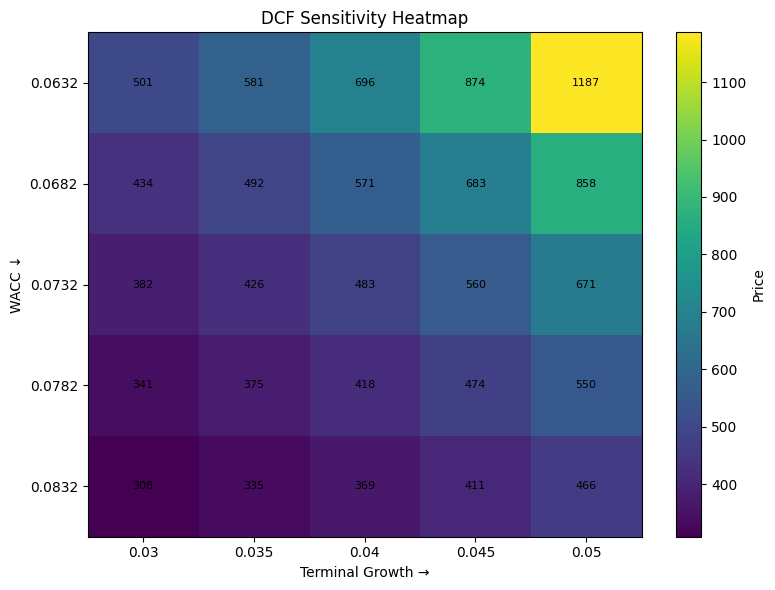

In [35]:
#DCF Sensitivity Heatmap
# ====================================================

# Convert to numeric (important)
heatmap_data = sensitivity_table.astype(float)

# Plot
plt.figure(figsize=(8, 6))

plt.imshow(heatmap_data, aspect='auto')

# Axis labels
plt.xticks(
    ticks=np.arange(len(heatmap_data.columns)),
    labels=np.round(heatmap_data.columns, 3)
)

plt.yticks(
    ticks=np.arange(len(heatmap_data.index)),
    labels=np.round(heatmap_data.index, 4)
)

# Titles
plt.xlabel("Terminal Growth →")
plt.ylabel("WACC ↓")
plt.title("DCF Sensitivity Heatmap")

# Color bar
plt.colorbar(label="Price")

# Annotate values inside cells
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]
        if not np.isnan(value):
            plt.text(j, i, f"{value:.0f}", ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [36]:
#Ratio Analysis : Capital Allocation
# ====================================================

from analysis.ratios.capital_ratios import *

market_cap = valuation_df["MarketCap"]

ratios_df = build_capital_ratios(full_df,ratios_df,market_cap)

ratios_df[["MarketCap","%_of_FCF_Returned","Shareholder_Yield","Payout_Ratio","FCF_After_Dividends","Buyback_to_FCF","Net_Shareholder_Return"]].T

,2022,2023,2024,2025,2026,2027,2028,2029,2030
MarketCap,3.600770e+11,4.576340e+11,5.374517e+11,6.559549e+11,6.786056e+11,7.372973e+11,7.987925e+11,8.627382e+11,9.288208e+11
%_of_FCF_Returned,8.273000e+01,8.048000e+01,1.119700e+02,1.063600e+02,9.236000e+01,9.181000e+01,8.976000e+01,8.795000e+01,8.634000e+01
Shareholder_Yield,4.110000e+00,3.460000e+00,3.890000e+00,3.500000e+00,3.470000e+00,3.490000e+00,3.500000e+00,3.510000e+00,3.520000e+00
Payout_Ratio,2.141000e+01,2.172000e+01,2.136000e+01,2.310000e+01,2.190000e+01,2.190000e+01,2.190000e+01,2.190000e+01,2.190000e+01
FCF_After_Dividends,2.108200e+04,2.344700e+04,2.291000e+04,2.621100e+04,3.048400e+04,3.351900e+04,3.710700e+04,4.088800e+04,4.485200e+04
Buyback_to_FCF,6.482000e+01,6.144000e+01,8.941000e+01,8.489000e+01,7.271000e+01,7.229000e+01,7.067000e+01,6.925000e+01,6.797000e+01
Net_Shareholder_Return,3.160000e+00,2.590000e+00,3.050000e+00,2.730000e+00,2.680000e+00,2.690000e+00,2.700000e+00,2.710000e+00,2.720000e+00


In [37]:
#Ratio Analysis : Industry + Risk Metric Analysis
# ====================================================

from analysis.ratios.risk_industry_ratios import *

ratios_df = build_risk_industry_ratios(full_df,ratios_df,growth_df)

ratios_df[["Revenue_vs_Volume_Gap","Cost_Rigidity","Debt_to_FCF_Years","Take_Rate_%","Revenue_per_Transaction"
,"Avg_Ticket_Size","Transactions_per_Dollar"]].T

,2022,2023,2024,2025,2026,2027,2028,2029,2030
Revenue_vs_Volume_Gap,NaN,5.37118,2.70651,3.76422,3.65620,3.40258,3.28647,3.18034,3.07740
Cost_Rigidity,NaN,59.18561,160.23766,139.20836,48.34187,100.10595,99.95427,99.97505,100.03717
Debt_to_FCF_Years,1.25566,1.03894,1.11464,1.16657,0.83834,0.90122,0.91165,0.90704,0.89724
Take_Rate_%,0.25267,0.26547,0.27217,0.28169,0.29144,0.30081,0.31019,0.31956,0.32893
Revenue_per_Transaction,0.01527,0.01536,0.01537,0.01553,0.01570,0.01590,0.01613,0.01637,0.01663
Avg_Ticket_Size,6.04167,5.78551,5.64585,5.51456,5.38793,5.28700,5.19973,5.12351,5.05636
Transactions_per_Dollar,0.16552,0.17285,0.17712,0.18134,0.18560,0.18914,0.19232,0.19518,0.19777


In [38]:
#Quality Score
# ====================================================

from analysis.scoring.quality import *

quality_df = build_quality_score(ratios_df)

quality_df

,Profitability_Quality,Return_Quality,Cash_Quality,Efficiency_Quality,BalanceSheet_Quality,Quality_Score
2022,0.61,0.00,1.00,0.30,0.11,41.92
2023,0.57,0.33,0.76,0.43,0.68,55.99
2024,0.92,0.86,0.00,0.61,0.58,60.98
2025,0.21,0.91,0.55,0.70,0.34,51.92
2026,0.45,1.00,0.68,1.00,0.98,79.35
2027,0.57,1.00,0.70,1.00,0.76,78.69
2028,0.70,1.00,0.81,1.00,0.58,80.06
2029,0.82,1.00,0.91,1.00,0.51,83.73
2030,0.94,1.00,1.00,1.00,0.59,90.20


In [39]:
#Risk Score
# ====================================================

from analysis.scoring.risk import *

risk_df = build_risk_score(ratios_df, growth_df)

risk_df

,Leverage_Risk,Coverage_Risk,Liquidity_Risk,CashStress_Risk,CashFlow_Risk,Operating_Risk,Volatility_Risk,Risk_Score,Safety_Score
2022,0.91,0.72,0.01,1.00,0.00,0.69,0.1,52.48,47.52
2023,0.08,1.00,0.00,0.00,0.24,0.50,0.1,25.40,74.60
2024,0.30,0.62,0.43,0.35,1.00,0.81,0.1,46.62,53.38
2025,0.85,0.05,1.00,0.59,0.48,0.40,0.0,50.43,49.57
2026,0.03,0.05,0.80,0.00,0.36,1.00,0.0,26.91,73.09
2027,0.42,0.05,0.62,0.00,0.32,0.70,0.0,28.75,71.25
2028,0.63,0.05,0.48,0.00,0.20,0.70,0.0,29.70,70.30
2029,0.78,0.05,0.36,0.00,0.12,0.70,0.0,29.93,70.07
2030,0.89,0.05,0.23,0.00,0.04,0.70,0.0,29.39,70.61


In [40]:
#Growth Score
# ====================================================

from analysis.scoring.growth import *

growth_score_df = build_growth_score(growth_df)

growth_score_df

,Revenue_Growth_Score,Earnings_Growth_Score,CashFlow_Growth_Score,Operating_Growth_Score,Reinvestment_Score,Growth_Score
2022,0.27,0.57,0.67,0.23,0.37,43.30
2023,0.27,0.57,0.67,0.23,0.37,43.30
2024,0.50,0.87,0.40,0.50,0.37,55.09
2025,0.48,0.47,0.50,0.26,0.50,45.05
2026,0.48,0.46,0.90,0.36,0.90,60.34
2027,0.10,0.68,0.80,0.20,0.50,45.97
2028,0.10,0.53,0.71,0.10,0.10,32.92
2029,0.10,0.50,0.72,0.10,0.10,32.32
2030,0.10,0.48,0.70,0.10,0.10,31.43


In [41]:
#Composite Score
# ====================================================

from analysis.scoring.composite import *

composite_df = build_composite_score(quality_df, growth_score_df, risk_df)

composite_df

,Quality_Score,Growth_Score,Risk_Score,Composite_Score
2022,41.92,43.30,52.48,23.52
2023,55.99,43.30,25.40,35.27
2024,60.98,55.09,46.62,37.40
2025,51.92,45.05,50.43,29.05
2026,79.35,60.34,26.91,51.44
2027,78.69,45.97,28.75,45.75
2028,80.06,32.92,29.70,41.61
2029,83.73,32.32,29.93,43.00
2030,90.20,31.43,29.39,45.71


In [42]:
#Investment Decision
# ====================================================

from analysis.decision.investment import *

terminal_growth = min(forecast["Revenue"].pct_change().replace([np.inf, -np.inf], np.nan).dropna().mean(), 0.05 - 0.01)

decision_df = build_decision(quality_df, growth_score_df, risk_df, valuation_summary, results_df, df, terminal_growth)

decision_df.T

,INVESTMENT_THESIS
Value_Score,84.61
Business_Score,49.15
Momentum_Score,67.54
Final_Score,68.79
Recommendation,BUY
Confidence_Score,68.78
Confidence,MEDIUM CONVICTION
DCF_Price,483.04
Bear_Price,375.42
Bull_Price,683.26


In [43]:
#Investment Decision (Narrative)
# ====================================================

from analysis.decision.narrative import *

decision_df = build_investment_thesis(decision_df,results_df)

decision_df.T

,INVESTMENT_THESIS
Value_Score,84.61
Business_Score,49.15
Momentum_Score,67.54
Final_Score,68.79
Recommendation,BUY
Confidence_Score,68.78
Confidence,MEDIUM CONVICTION
DCF_Price,483.04
Bear_Price,375.42
Bull_Price,683.26


In [44]:
#Driver Scenarios
# ====================================================

from analysis.driver_scenarios import *

driver_scenario_df = build_driver_scenarios(growth_df)

driver_scenario_df

,Revenue_Growth%,OperatingIncome_Growth%,NetIncome_Growth%,EPS_Growth%,EBITDA_Growth%,FreeCashFlow_Growth%,PaymentVolume_Growth%,Transactions_Growth%,OperatingExpense_Growth%,Dividends_Growth%,Shares_Growth%,OperatingCashFlow_Growth%,Capex_Growth%,TotalAssets_Growth%,TotalLiabilities_Growth%,Equity_Growth%,Scenario
2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Bear
2023,9.4057,9.8120,13.8844,16.6857,15.8126,8.6628,6.0345,10.7292,6.7505,17.1090,-2.6204,8.6119,9.1753,5.8456,3.6979,8.8587,Bear
2024,8.0236,8.1140,12.6998,15.9121,13.1144,-6.5924,7.3171,9.9718,16.0616,12.4233,-2.5224,-5.3786,18.6969,4.4332,6.9698,1.0430,Bear
2025,9.3400,8.7878,-0.0045,3.2304,1.6099,13.9282,7.5758,10.1369,15.7862,9.8886,-2.3859,14.0840,17.8998,5.4131,11.4566,-3.1377,Bear
2026,7.2900,8.5521,12.3396,12.0274,14.3945,16.5841,5.6338,8.1165,4.4910,8.0060,0.3707,15.5129,1.4170,2.4331,0.3289,3.4055,Bear
2027,7.2026,7.6028,7.8119,7.3732,9.2012,8.5632,5.8000,7.8197,9.2123,9.4106,0.4034,8.5178,9.2482,6.9397,11.0673,3.5918,Bear
2028,6.7685,7.1685,7.0343,6.5552,8.7707,9.6115,5.4820,7.2526,8.7645,8.6194,0.4371,9.4820,8.7698,6.5828,8.9743,3.7727,Bear
2029,6.3775,6.7753,6.7162,6.2331,8.3777,9.0459,5.1971,6.7621,8.3754,8.3221,0.4715,8.9265,8.3427,6.6594,7.9711,3.9416,Bear
2030,6.0178,6.4175,6.3870,5.8677,8.0173,8.5131,4.9404,6.3338,8.0208,7.9932,0.5069,8.4093,8.0620,6.8852,7.3987,4.0981,Bear
2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Base


In [45]:
# Tableau Export
# ====================================================

from data.export_tableau import *

export = export_for_tableau(
        df,
        full_df,
        growth_df,
        ratios_df,
        valuation_df,
        diagnostic_df,
        results_df,
        valuation_summary,
        sensitivity_table,
        quality_df,
        risk_df,
        growth_score_df,
        composite_df,
        decision_df,
        driver_scenario_df
    )


historical_data.csv - (4, 76)
full_df.csv - (9, 77)
growth_df.csv - (9, 17)
ratios_df.csv - (9, 57)
valuation_df.csv - (9, 65)
diagnostic_df.csv - (9, 21)
results_df.csv - (3, 6)
valuation_summary.csv - (1, 10)
sensitivity_table.csv - (25, 4)
score_df.csv - (9, 23)
decision_df.csv - (1, 26)
driver_scenario_df.csv - (27, 18)

All Tableau exports completed successfully.
